# 03. 데이터 2,3차 전처리 및 EDA

# 작업 순서

<2차 전처리>
1.   위,경도 산출
2.   결측치 제거&대체
3. 추가 파생변수 생성
4. Train / Test set 분할

<2차 EDA>

5. 거리 변수 재설계
6. 데이터 신뢰성 검증
7. 타겟 변수 분포 + 정규성 검정 (Shapiro-Wilk)
8. 범주형 변수 분포 + 연관성 검정
9. 상관관계(피어슨/스피어만) + VIF — 재설계된 거리 변수 반영
10. 전용면적 vs 면적당가격 — 비선형 관계
11. SK미래관/보문역 개별 거리 구간별 패턴 재확인
12. 반지하(is_basement) 효과 — t-test · Mann-Whitney U · Cohen's d · 부트스트랩 CI
13. 면적라벨(소형/중형/대형) 그룹 차이 — ANOVA & Kruskal-Wallis
14. 동그룹 · 주택유형 심화 — 면적 교란 여부 확인
15. 갱신계약 인상률 — 전월세상한제(5%) 점검

<종합 정리 - 2차 EDA>

<3차 전처리>

16. 거리 변수 재정의
17. 면적 비선형성 대응
18. 타겟 변수 확정
19. 구조적 결측 처리 방침
20. 이상치 플래그 처리
21. 범주형 변수 인코딩
22. Train / Test 분할 (data_split 생성)
23. 최종 모델링 피처셋 정의
24. 최종 검증 & 저장



In [36]:
DATA_PATH = 'dataset_preprocessed_ML1조.csv'
df = pd.read_csv(DATA_PATH)
print(f"▶ 초기 데이터 크기: {df.shape[0]}행")

▶ 초기 데이터 크기: 1307행


In [57]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm8. 범주형 변수 분포 + 연관성 검정
sns.set_style('whitegrid')
_candidates = ['NanumGothic', 'Noto Sans CJK JP', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
_available = {f.name for f in fm.fontManager.ttflist}
_picked = next((n for n in _candidates if n in _available), None)
if _picked:
    plt.rcParams['font.family'] = _picked
else:
    print("한글 폰트를 찾지 못했습니다. Colab이면 fonts-nanum 설치 후 런타임을 재시작하세요.")
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'], fontext='ttf'):
    fm.fontManager.addfont(f)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

한글 폰트를 찾지 못했습니다. Colab이면 fonts-nanum 설치 후 런타임을 재시작하세요.


# 1. 위, 경도 산출

In [ ]:
from google.colab import userdata
import requests
import time
import folium

KAKAO_KEY = userdata.get("KAKAO_API_KEY")


# 1. 주소 생성 — "서울특별시" 추가
df["주소"] = "서울특별시 " + df["_구"] + " " + df["읍면동"] + " " + df["지번"].astype(str)


# 2. 지오코딩
def geocode(address, api_key):
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params = {"query": address}
    try:
        r = requests.get(url, headers=headers, params=params, timeout=10)
        docs = r.json().get("documents", [])
        if docs:
            return float(docs[0]["y"]), float(docs[0]["x"])
    except Exception as e:
        print(f"에러: {address} / {e}")
    return None, None


dong_coord_cache = {}

def geocode_dong(dong_name, api_key):
    if dong_name in dong_coord_cache:
        return dong_coord_cache[dong_name]
    addr = f"서울특별시 성북구 {dong_name}"
    lat, lon = geocode(addr, api_key)
    dong_coord_cache[dong_name] = (lat, lon)
    return lat, lon


# 3. 전체 매물 지오코딩
unique_addr = df[["주소", "읍면동"]].drop_duplicates()
addr_coord = {}
fail_count = 0

for _, row in unique_addr.iterrows():
    addr, dong = row["주소"], row["읍면동"]
    lat, lon = geocode(addr, KAKAO_KEY)
    if lat is None:
        # 지번주소 실패 → 동 중심좌표로 fallback
        lat, lon = geocode_dong(dong, KAKAO_KEY)
        fail_count += 1
    addr_coord[addr] = (lat, lon)
    time.sleep(0.05)

print(f"지번 정확매칭 실패 → 동단위 fallback 처리: {fail_count} / {len(unique_addr)}건")

# 4. df에 좌표 merge
df["위도"] = df["주소"].map(lambda x: addr_coord.get(x, (None, None))[0])
df["경도"] = df["주소"].map(lambda x: addr_coord.get(x, (None, None))[1])

n_success = df["위도"].notna().sum()
print(f"최종 표시 가능: {n_success} / {len(df)}건 ({n_success/len(df)*100:.1f}%)")


# 5. 지도에 전체 빨간 점으로 표시
df_geo = df.dropna(subset=["위도", "경도"])

m = folium.Map(location=[37.5863, 127.0250], zoom_start=15)

for _, row in df_geo.iterrows():
    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=3,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['건물명']} / {row['주소']}",
    ).add_to(m)

m


In [ ]:
REF_LAT, REF_LON = 37.5863, 127.0270

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["학교거리_m"] = haversine(df["위도"], df["경도"], REF_LAT, REF_LON)

# 2. 결측치 제거&대체



- 계약기간 결측치 제거
- 계약구분 결측치 -> '신규'로 대체
- '연립다세대' -> '다세대'로 대체
- '종전환산보증금_만원' 산출






In [37]:
# 1. 계약기간 결측치 제거
df['계약기간'] = df['계약기간'].replace(r'^\s*$', np.nan, regex=True)
df_clean_term = df.dropna(subset=['계약기간']).copy()

dropped_count = len(df) - len(df_clean_term)

# 2. 계약구분 결측치 대체
df_clean_term['계약구분'] = df_clean_term['계약구분'].replace(r'^\s*$', '신규', regex=True)

# 3. 주택유형 '연립다세대' -> '다세대'로 교체
df_clean_term['주택유형'] = df_clean_term['주택유형'].replace('연립다세대', '다세대')

# 4. '종전환산보증금_만원' 산출
cond_renewal = df_clean_term['계약구분'] == '갱신'
df_clean_term.loc[cond_renewal, '종전보증금_만원'] = df_clean_term.loc[cond_renewal, '종전보증금_만원'].fillna(0)
df_clean_term.loc[cond_renewal, '종전월세_만원'] = df_clean_term.loc[cond_renewal, '종전월세_만원'].fillna(0)
df_clean_term['종전환산보증금_만원'] = df_clean_term['종전보증금_만원'] + (df_clean_term['종전월세_만원'] * 12) / (df_clean_term['동북권_전환율(%)'] / 100)

In [38]:
df = df_clean_term.copy()

In [39]:
# 2. 결측치 확인 (종전보증금/월세 외에 위경도, 거리에 결측치가 있으면 안 됨)
missing_info = df.isnull().sum()
missing_cols = missing_info[missing_info > 0]
if len(missing_cols) > 0:
    print("▶ 결측치가 존재하는 컬럼:")
    print(missing_cols)
else:
    print("▶ 결측치: 없음! 완벽합니다.")

print("\n" + "="*50)
print("🗺️ [STEP 2] 새로 추가된 공간 변수(위경도, 거리) 이상치 점검")
print("="*50)
# 위도, 경도, 거리 관련 컬럼만 추출해서 통계량 확인
space_cols = [col for col in df.columns if '위도' in col or '경도' in col or '거리' in col or '역' in col]
display(df[space_cols].describe(include='all').round(4))


▶ 결측치가 존재하는 컬럼:
종전보증금_만원      1109
종전월세_만원       1109
종전환산보증금_만원    1109
dtype: int64

🗺️ [STEP 2] 새로 추가된 공간 변수(위경도, 거리) 이상치 점검


,위도,경도,지하철역거리_m,최근접역
count,1286.0000,1286.0000,1286.0000,1286
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,보문역
freq,NaN,NaN,NaN,903
mean,37.5851,127.0229,329.0276,NaN
std,0.0030,0.0043,165.4697,NaN
min,37.5786,127.0174,92.0775,NaN
25%,37.5823,127.0194,202.3503,NaN
50%,37.5855,127.0216,291.2139,NaN
75%,37.5876,127.0282,404.4035,NaN


# 3. 추가 파생변수 생성



*   'is_basement' 생성 -> 반지하 여부 분할


*   '학교까지와의 거리' 변수 생성 (문캠 중심: 'SK미래관', 이캠 중심: '하나스퀘어'로 설정)





SK미래관 위,경도 좌표: 37.5843, 127.0305

하나스퀘어 위, 경도 좌표: 37.5828, 127.0270

In [40]:
# 1. is_basement 파생변수 생성
df['is_basement'] = (df['층'] <= 0).astype(int)

# 2. 건물 대표 위경도 설정
SK_FUTURES_LAT, SK_FUTURES_LON = 37.5843, 127.0305
HANA_SQUARE_LAT, HANA_SQUARE_LON = 37.5828, 127.0270

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


# 3. 학교 거점 건물별 거리 계산 및 최소 거리 확정
dist_sk = haversine_distance(df['위도'], df['경도'], SK_FUTURES_LAT, SK_FUTURES_LON)
dist_hana = haversine_distance(df['위도'], df['경도'], HANA_SQUARE_LAT, HANA_SQUARE_LON)

df['학교거리_m'] = np.minimum(dist_sk, dist_hana)

# 4. Train / Test set 분할



*   train(2023~2024)
*   test(2025~2026)



In [41]:
train_df = df[df['계약연도'] <= 2024].copy()
test_df = df[df['계약연도'] >= 2025].copy()

print(f"▶ Train 데이터 (2023~2024년): {len(train_df)}건 ({len(train_df)/len(df)*100:.1f}%)")
print(f"▶ Test 데이터 (2025~2026년): {len(test_df)}건 ({len(test_df)/len(df)*100:.1f}%)")

▶ Train 데이터 (2023~2024년): 694건 (54.0%)
▶ Test 데이터 (2025~2026년): 592건 (46.0%)


In [ ]:
SAVE_PATH = 'eda_안암보문_final.csv'
df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')

**※ 이후 EDA는 Train Dataset만 하는 것으로 한정.**

In [44]:
df = df[df['계약연도'] <= 2024].reset_index(drop=True)
print(f"전체: {df.shape[0]}행 / Train(23~24): {df.shape[0]}행")
target = '면적당가격_만원'

전체: 694행 / Train(23~24): 694행


# 5. 거리 변수 재설계

In [45]:
SK_LAT, SK_LON = 37.5843, 127.0305        # SK미래관
HANA_LAT, HANA_LON = 37.5828, 127.0270    # 하나스퀘어
ANAM_LAT, ANAM_LON = 37.586331, 127.029231   # 안암역
BOMUN_LAT, BOMUN_LON = 37.58556, 127.01972   # 보문역

for name, (lat, lon) in [('SK미래관거리', (SK_LAT, SK_LON)), ('하나스퀘어거리', (HANA_LAT, HANA_LON)),
                          ('안암역거리', (ANAM_LAT, ANAM_LON)), ('보문역거리', (BOMUN_LAT, BOMUN_LON))]:
    df[name]= haversine_distance(df['위도'], df['경도'], lat, lon)

check_diff = (df[['안암역거리','보문역거리']].min(axis=1) - df['지하철역거리_m']).abs()
print(f"좌표 검증 — 기존 지하철역거리_m 과의 평균 오차: {check_diff.mean():.1f}m (최대 {check_diff.max():.1f}m) → 좌표 신뢰 가능")

좌표 검증 — 기존 지하철역거리_m 과의 평균 오차: 10.4m (최대 25.1m) → 좌표 신뢰 가능


In [46]:
print("=== 개별 지점 거리 vs 기존 min() 방식 — 피어슨/스피어만 비교 ===")
rows = []
for col, label in [('SK미래관거리','학교(SK미래관)'), ('하나스퀘어거리','학교(하나스퀘어)'), ('학교거리_m','학교(기존 min)'),
                    ('안암역거리','지하철(안암역)'), ('보문역거리','지하철(보문역)'), ('지하철역거리_m','지하철(기존 min)')]:
    p = df[col].corr(df[target], method='pearson')
    s = df[col].corr(df[target], method='spearman')
    rows.append({'변수': label, '피어슨': p, '스피어만': s, '평균거리(m)': df[col].mean()})
print(pd.DataFrame(rows).to_string(index=False))

=== 개별 지점 거리 vs 기존 min() 방식 — 피어슨/스피어만 비교 ===
         변수       피어슨      스피어만    평균거리(m)
  학교(SK미래관) -0.329740 -0.283842 787.212618
  학교(하나스퀘어) -0.030991 -0.057124 631.421550
 학교(기존 min) -0.181319 -0.170554 587.791968
   지하철(안암역) -0.396323 -0.299022 702.541631
   지하철(보문역)  0.398804  0.320629 504.918967
지하철(기존 min) -0.157421 -0.181628 334.465690


In [47]:
def compute_vif(df_, cols):
    X = df_[cols].astype(float).values
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    out = []
    for i in range(X.shape[1]):
        y = X[:, i]
        others = np.delete(X, i, axis=1)
        oc = np.column_stack([others, np.ones(len(others))])
        coef, *_ = np.linalg.lstsq(oc, y, rcond=None)
        pred = oc @ coef
        r2 = 1 - np.sum((y-pred)**2) / np.sum((y-y.mean())**2)
        out.append(1/(1-r2) if r2 < 1 else np.inf)
    return pd.DataFrame({'feature': cols, 'VIF': out})

feat4 = ['전용면적_m2','층','주택연령','is_basement','SK미래관거리','하나스퀘어거리','안암역거리','보문역거리']
print("=== 4개 거리변수 모두 포함 시 VIF (다중공선성 재확인) ===")
print(compute_vif(df, feat4).to_string(index=False))
print()
print("=== 4개 거리변수 상호 상관관계 ===")
print(df[['SK미래관거리','하나스퀘어거리','안암역거리','보문역거리']].corr().round(3))

=== 4개 거리변수 모두 포함 시 VIF (다중공선성 재확인) ===
    feature       VIF
    전용면적_m2  1.521563
          층  1.223647
       주택연령  1.599214
is_basement  1.114058
    SK미래관거리 66.136776
    하나스퀘어거리 10.540591
      안암역거리 29.898904
      보문역거리  3.369698

=== 4개 거리변수 상호 상관관계 ===
         SK미래관거리  하나스퀘어거리  안암역거리  보문역거리
SK미래관거리    1.000    0.748  0.929 -0.755
하나스퀘어거리    0.748    1.000  0.492 -0.440
안암역거리      0.929    0.492  1.000 -0.695
보문역거리     -0.755   -0.440 -0.695  1.000


In [48]:
feat2 = ['전용면적_m2','층','주택연령','is_basement','안암역거리','보문역거리']
print("=== 최종 추천 조합(안암역거리+보문역거리만) VIF ===")
print(compute_vif(df, feat2).to_string(index=False))

=== 최종 추천 조합(안암역거리+보문역거리만) VIF ===
    feature      VIF
    전용면적_m2 1.407154
          층 1.200330
       주택연령 1.582744
is_basement 1.109527
      안암역거리 1.984690
      보문역거리 2.004204


In [49]:
def partial_corr(x, y, z):
    rxy, rxz, ryz = np.corrcoef(x,y)[0,1], np.corrcoef(x,z)[0,1], np.corrcoef(y,z)[0,1]
    return (rxy - rxz*ryz) / np.sqrt((1-rxz**2)*(1-ryz**2))

area = df['전용면적_m2']
print("=== 면적을 통제한 편상관 (거리효과가 면적 차이 때문인지 확인) ===")
for col in ['안암역거리','보문역거리']:
    raw = df[col].corr(df[target])
    pc = partial_corr(df[col], df[target], area)
    print(f"{col:10s} 단순상관={raw:+.4f}   면적통제후 편상관={pc:+.4f}")

=== 면적을 통제한 편상관 (거리효과가 면적 차이 때문인지 확인) ===
안암역거리      단순상관=-0.3963   면적통제후 편상관=-0.3848
보문역거리      단순상관=+0.3988   면적통제후 편상관=+0.3657


In [50]:
feat2b = ['전용면적_m2','층','주택연령','is_basement','SK미래관거리','보문역거리']
print("=== 채택안: SK미래관거리(학교)+보문역거리(지하철) VIF ===")
print(compute_vif(df, feat2b).to_string(index=False))
print()
print(f"SK미래관거리-보문역거리 상관계수: {df['SK미래관거리'].corr(df['보문역거리']):.3f}")

=== 채택안: SK미래관거리(학교)+보문역거리(지하철) VIF ===
    feature      VIF
    전용면적_m2 1.390697
          층 1.199545
       주택연령 1.563190
is_basement 1.112707
    SK미래관거리 2.375987
      보문역거리 2.442525

SK미래관거리-보문역거리 상관계수: -0.755


In [51]:
def fit_r2(df_, cols, target_col='면적당가격_만원'):
    X = df_[cols].astype(float).values
    X = np.column_stack([X, np.ones(len(X))])
    y = df_[target_col].values
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    pred = X @ coef
    return 1 - np.sum((y-pred)**2) / np.sum((y-y.mean())**2)

old_feats = ['전용면적_m2','층','주택연령','is_basement','학교거리_m','지하철역거리_m']
new_feats = ['전용면적_m2','층','주택연령','is_basement','SK미래관거리','보문역거리']
r2_old = fit_r2(df, old_feats)
r2_new = fit_r2(df, new_feats)
print(f"기존 변수(학교거리_m + 지하철역거리_m) 회귀 R²:    {r2_old:.4f}")
print(f"재설계 변수(SK미래관거리 + 보문역거리) 회귀 R²:  {r2_new:.4f}")
print(f"개선폭: +{(r2_new-r2_old):.4f}  (상대적으로 {(r2_new/r2_old-1)*100:.1f}% 개선)")

기존 변수(학교거리_m + 지하철역거리_m) 회귀 R²:    0.5319
재설계 변수(SK미래관거리 + 보문역거리) 회귀 R²:  0.5529
개선폭: +0.0211  (상대적으로 4.0% 개선)


# 6. 데이터 신뢰성 검증

In [52]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("=== 결측치 현황 ===")
print(missing)
cross = pd.crosstab(df['종전보증금_만원'].isnull(), df['계약구분'])
print("\n=== 결측 여부 x 계약구분 교차표 ===")
print(cross)

=== 결측치 현황 ===
종전보증금_만원      605
종전월세_만원       605
종전환산보증금_만원    605
dtype: int64

=== 결측 여부 x 계약구분 교차표 ===
계약구분      갱신   신규
종전보증금_만원         
False     89    0
True       0  605


In [53]:
print("=== 이상치후보 분포 ===")
print(df['이상치후보'].value_counts())
print(f"|z| 최댓값: {df['z_면적당가격'].abs().max():.3f}, |z|>=2 인 건수: {(df['z_면적당가격'].abs()>=2).sum()}")

=== 이상치후보 분포 ===
이상치후보
False    694
Name: count, dtype: int64
|z| 최댓값: 2.777, |z|>=2 인 건수: 22


# 7. 타겟 변수 분포 + 정규성 검정 (Shapiro-Wilk)

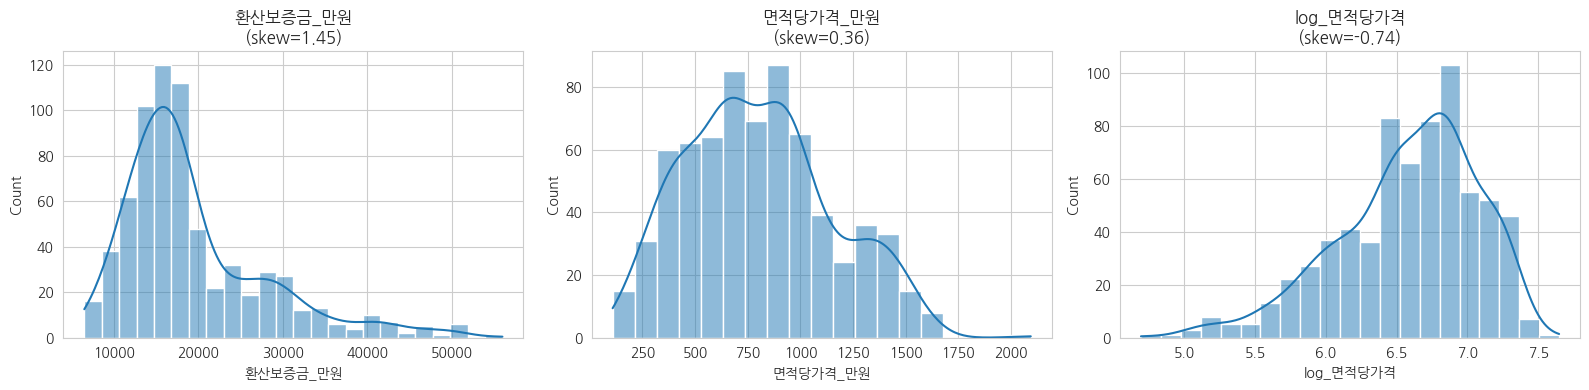

=== Shapiro-Wilk 정규성 검정 (H0: 정규분포이다) ===
면적당가격_만원        skew=0.355  W=0.9796  p=3.06e-08  정규분포 아님
log_면적당가격       skew=-0.743  W=0.9608  p=1.17e-12  정규분포 아님


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cols3 = ['환산보증금_만원', '면적당가격_만원', 'log_면적당가격']
for ax, col in zip(axes, cols3):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"{col}\n(skew={stats.skew(df[col]):.2f})")
plt.tight_layout()
plt.show()

print("=== Shapiro-Wilk 정규성 검정 (H0: 정규분포이다) ===")
for col in ['면적당가격_만원', 'log_면적당가격']:
    stat, p = stats.shapiro(df[col])
    print(f"{col:15s} skew={stats.skew(df[col]):.3f}  W={stat:.4f}  p={p:.2e}  {'정규분포 아님' if p<0.05 else '기각 못함'}")

# 8. 범주형 변수 분포 + 연관성 검정

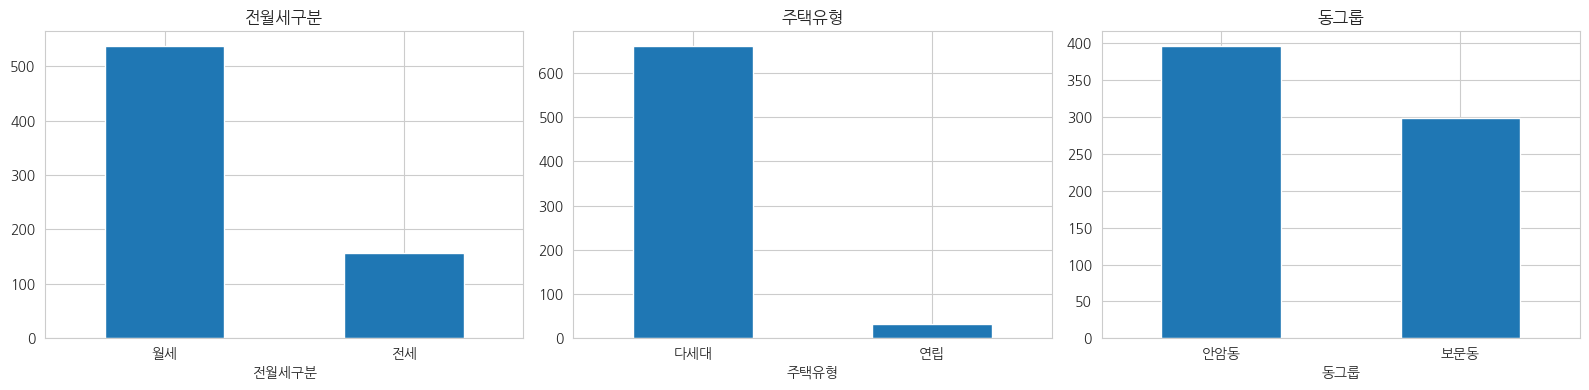

전월세구분 {'월세': 537, '전세': 157}
주택유형 {'다세대': 661, '연립': 33}
동그룹 {'안암동': 396, '보문동': 298}


In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['전월세구분', '주택유형', '동그룹']):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

for col in ['전월세구분', '주택유형', '동그룹']:
    print(col, df[col].value_counts().to_dict())

In [60]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
    return chi2, p, v

print("=== 범주형 변수 간 카이제곱 독립성 검정 (H0: 서로 독립이다) ===")
for c1, c2 in [('전월세구분','동그룹'), ('주택유형','동그룹'), ('전월세구분','최근접역')]:
    chi2, p, v = cramers_v(df[c1], df[c2])
    print(f"{c1} x {c2:8s}: chi2={chi2:6.2f}  p={p:.2e}  Cramér's V={v:.3f}  {'연관 있음' if p<0.05 else '독립'}")

print()
print("=== 동그룹별 전월세구분/주택유형 비율 ===")
print(pd.crosstab(df['동그룹'], df['전월세구분'], normalize='index').round(3))
print(pd.crosstab(df['동그룹'], df['주택유형'], normalize='index').round(3))

=== 범주형 변수 간 카이제곱 독립성 검정 (H0: 서로 독립이다) ===
전월세구분 x 동그룹     : chi2= 19.49  p=1.01e-05  Cramér's V=0.168  연관 있음
주택유형 x 동그룹     : chi2= 20.85  p=4.98e-06  Cramér's V=0.173  연관 있음
전월세구분 x 최근접역    : chi2= 17.92  p=2.30e-05  Cramér's V=0.161  연관 있음

=== 동그룹별 전월세구분/주택유형 비율 ===
전월세구분     월세     전세
동그룹                
보문동    0.691  0.309
안암동    0.836  0.164
주택유형    다세대     연립
동그룹               
보문동   0.997  0.003
안암동   0.919  0.081


# 9. 상관관계(피어슨/스피어만) + VIF — 재설계된 거리 변수 반영

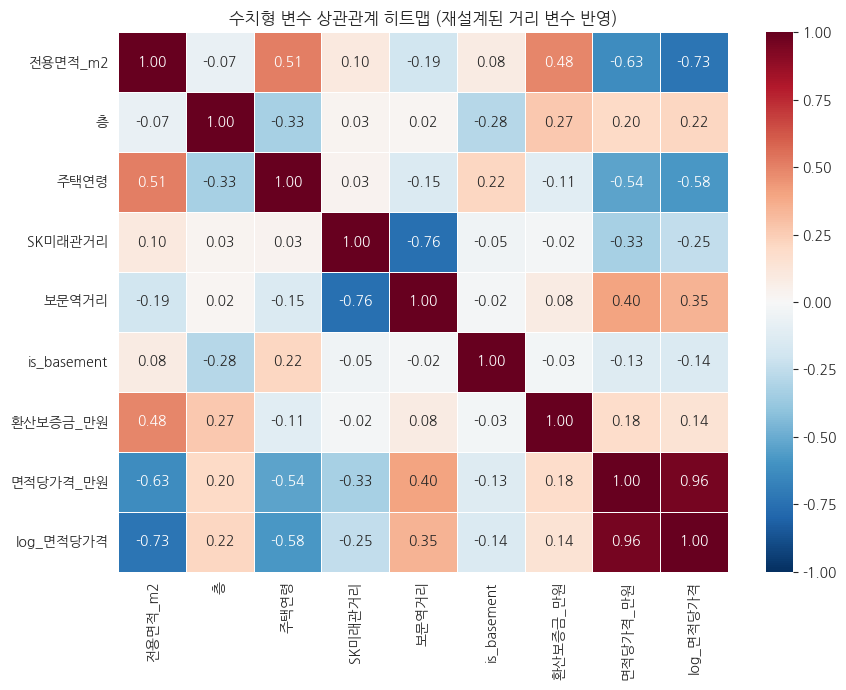

In [61]:
num_cols = ['전용면적_m2', '층', '주택연령', 'SK미래관거리', '보문역거리', 'is_basement',
            '환산보증금_만원', '면적당가격_만원', 'log_면적당가격']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('수치형 변수 상관관계 히트맵 (재설계된 거리 변수 반영)')
plt.tight_layout()
plt.show()

In [62]:
vars_ = ['전용면적_m2', '층', '주택연령', 'SK미래관거리', '보문역거리']
pearson = [df[target].corr(df[v], method='pearson') for v in vars_]
spearman = [df[target].corr(df[v], method='spearman') for v in vars_]
corr_table = pd.DataFrame({'변수': vars_, '피어슨': pearson, '스피어만': spearman})
print(f"=== {target} 과의 상관계수 (피어슨 vs 스피어만) ===")
print(corr_table.to_string(index=False))
print()

feat_final = ['전용면적_m2', '층', '주택연령', 'is_basement', 'SK미래관거리', '보문역거리']
print("=== VIF (재설계된 최종 피처셋) ===")
print(compute_vif(df, feat_final).to_string(index=False))

=== 면적당가격_만원 과의 상관계수 (피어슨 vs 스피어만) ===
     변수       피어슨      스피어만
전용면적_m2 -0.631037 -0.679782
      층  0.202380  0.225016
   주택연령 -0.537930 -0.540141
SK미래관거리 -0.329740 -0.283842
  보문역거리  0.398804  0.320629

=== VIF (재설계된 최종 피처셋) ===
    feature      VIF
    전용면적_m2 1.390697
          층 1.199545
       주택연령 1.563190
is_basement 1.112707
    SK미래관거리 2.375987
      보문역거리 2.442525


# 10. 전용면적 vs 면적당가격 — 비선형 관계

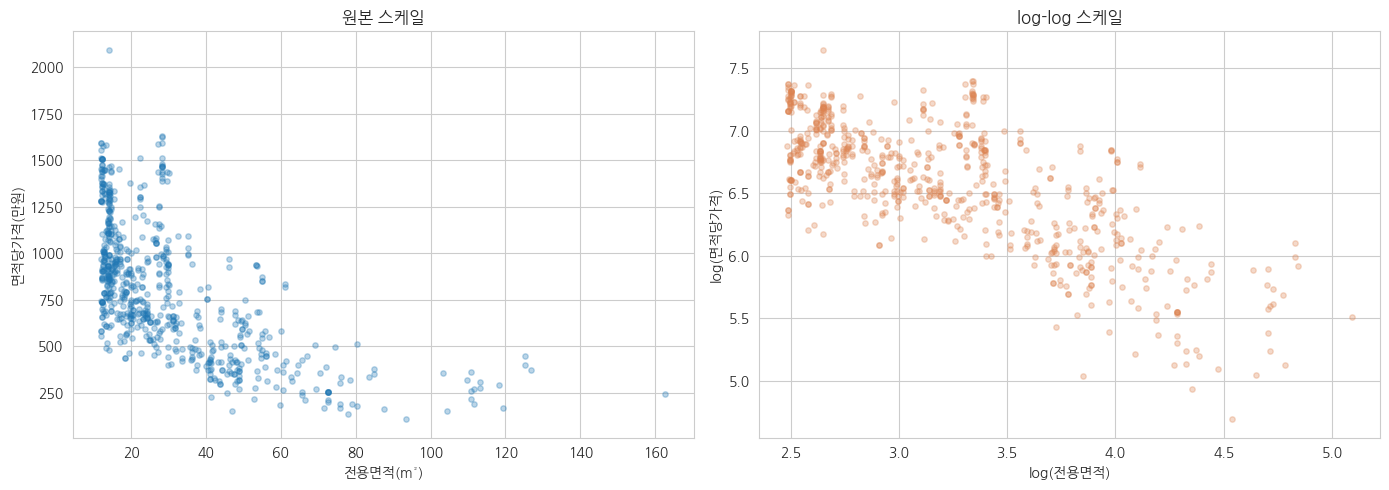

원본 스케일 상관계수: -0.631  /  log-log 스케일 상관계수: -0.744

            mean      median  count
면적라벨                               
소형    992.905705  945.707071    309
중형    865.588759  795.720495    183
대형    454.125717  417.279412    202


In [63]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['전용면적_m2'], df['면적당가격_만원'], alpha=0.3, s=15)
axes[0].set_xlabel('전용면적(m²)'); axes[0].set_ylabel('면적당가격(만원)')
axes[0].set_title('원본 스케일')

axes[1].scatter(np.log(df['전용면적_m2']), df['log_면적당가격'], alpha=0.3, s=15, color='#DD8452')
axes[1].set_xlabel('log(전용면적)'); axes[1].set_ylabel('log(면적당가격)')
axes[1].set_title('log-log 스케일')
plt.tight_layout()
plt.show()

r_raw = df['전용면적_m2'].corr(df['면적당가격_만원'])
r_loglog = np.log(df['전용면적_m2']).corr(df['log_면적당가격'])
print(f"원본 스케일 상관계수: {r_raw:.3f}  /  log-log 스케일 상관계수: {r_loglog:.3f}")
print()
by_size = df.groupby('면적라벨', observed=True)['면적당가격_만원'].agg(['mean','median','count']).reindex(['소형','중형','대형'])
print(by_size)


# 11. SK미래관/보문역 개별 거리 구간별 패턴 재확인

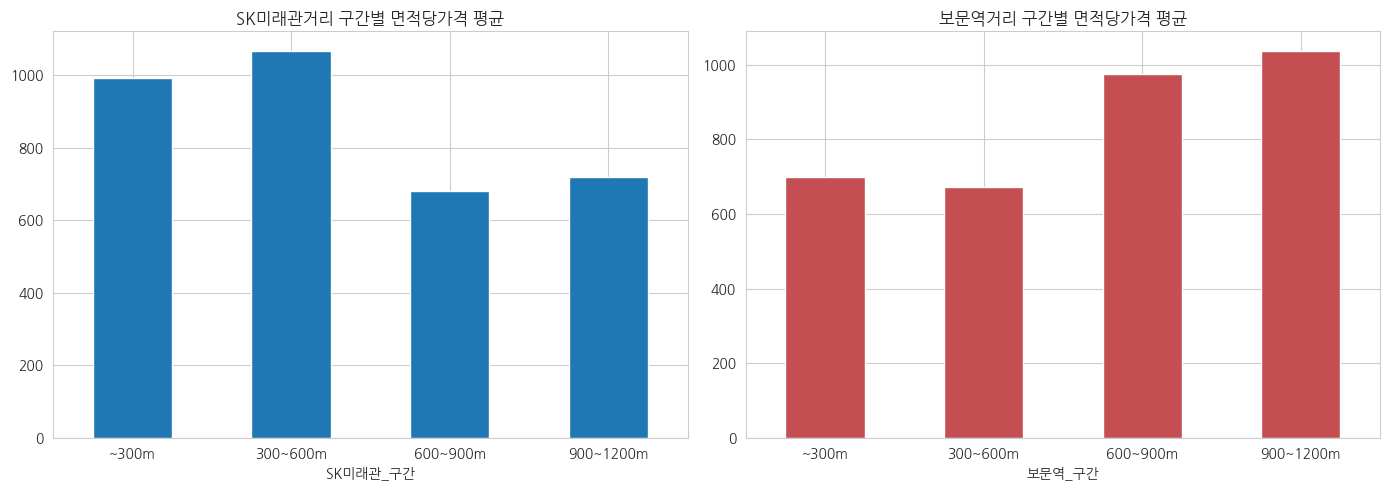

=== SK미래관거리 구간별 ===
                  mean       median  count
SK미래관_구간                                  
~300m       991.670767  1077.366814     54
300~600m   1068.136476  1163.017032    143
600~900m    679.634127   689.655172    176
900~1200m   719.734134   676.234349    321

=== 보문역거리 구간별 ===
                  mean       median  count
보문역_구간                                    
~300m       700.350754   676.234349    237
300~600m    671.226009   650.118196    198
600~900m    975.118001   968.361483    171
900~1200m  1037.647092  1013.193486     88


In [64]:

bins = [0, 300, 600, 900, 1200, 3000]
labels = ['~300m', '300~600m', '600~900m', '900~1200m', '1200m~']
df['SK미래관_구간'] = pd.cut(df['SK미래관거리'], bins=bins, labels=labels)
df['보문역_구간'] = pd.cut(df['보문역거리'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('SK미래관_구간', observed=True)[target].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('SK미래관거리 구간별 면적당가격 평균'); axes[0].tick_params(axis='x', rotation=0)
df.groupby('보문역_구간', observed=True)[target].mean().plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('보문역거리 구간별 면적당가격 평균'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("=== SK미래관거리 구간별 ===")
print(df.groupby('SK미래관_구간', observed=True)[target].agg(['mean','median','count']))
print()
print("=== 보문역거리 구간별 ===")
print(df.groupby('보문역_구간', observed=True)[target].agg(['mean','median','count']))

In [65]:
a = df[df['최근접역']=='안암역'][target]
b = df[df['최근접역']=='보문역'][target]
t, p = stats.ttest_ind(a, b, equal_var=False)
dong_a = df[df['동그룹']=='안암동'][target]
dong_b = df[df['동그룹']=='보문동'][target]
print(f"최근접역 기준 — 안암역 권역 평균={a.mean():.1f}(n={len(a)})  보문역 권역 평균={b.mean():.1f}(n={len(b)})  격차={((a.mean()/b.mean()-1)*100):.1f}%  p={p:.2e}")
print(f"동그룹 기준   — 안암동 평균={dong_a.mean():.1f}(n={len(dong_a)})  보문동 평균={dong_b.mean():.1f}(n={len(dong_b)})  격차={((dong_a.mean()/dong_b.mean()-1)*100):.1f}%")


최근접역 기준 — 안암역 권역 평균=1042.0(n=202)  보문역 권역 평균=704.2(n=492)  격차=48.0%  p=1.37e-25
동그룹 기준   — 안암동 평균=857.7(n=396)  보문동 평균=729.2(n=298)  격차=17.6%


# 12. 반지하(`is_basement`) 효과 — t-test · Mann-Whitney U · Cohen's d · 부트스트랩 CI

/tmp/ipykernel_1189/230579311.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'지상(n={len(b0)})', f'반지하(n={len(b1)})'])


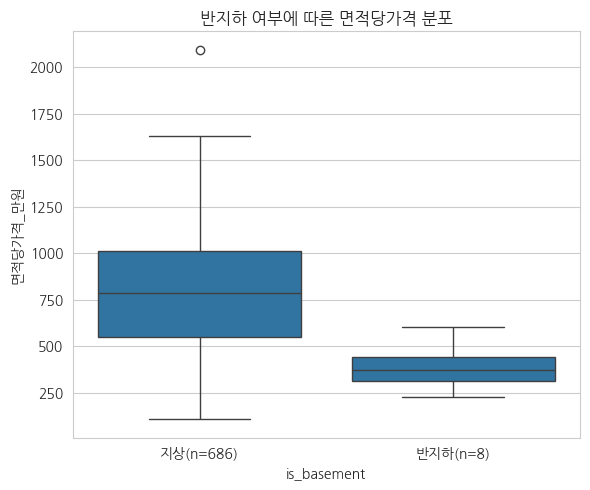

지상 평균=807.3   반지하 평균=388.3   (반지하/지상 비율 48.1%)
t-test:          t=9.779  p=6.23e-06
Mann-Whitney U:  U=4803.0  p=2.61e-04  (비모수, 소표본에 더 안전)
Cohen's d = 1.214  (0.8 이상이면 large)
부트스트랩 95% CI (평균차): [338.1, 495.1]만원/m²


In [66]:
b0 = df[df['is_basement']==0][target].values
b1 = df[df['is_basement']==1][target].values

t_stat, p_t = stats.ttest_ind(b0, b1, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(b0, b1, alternative='two-sided')
pooled_std = np.sqrt(((len(b0)-1)*b0.std()**2 + (len(b1)-1)*b1.std()**2) / (len(b0)+len(b1)-2))
cohend = (b0.mean() - b1.mean()) / pooled_std

np.random.seed(42)
diffs = [np.random.choice(b0, len(b0), replace=True).mean() - np.random.choice(b1, len(b1), replace=True).mean()
         for _ in range(5000)]
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='is_basement', y=target, ax=ax)
ax.set_xticklabels([f'지상(n={len(b0)})', f'반지하(n={len(b1)})'])
ax.set_title('반지하 여부에 따른 면적당가격 분포')
plt.tight_layout()
plt.show()

print(f"지상 평균={b0.mean():.1f}   반지하 평균={b1.mean():.1f}   (반지하/지상 비율 {b1.mean()/b0.mean()*100:.1f}%)")
print(f"t-test:          t={t_stat:.3f}  p={p_t:.2e}")
print(f"Mann-Whitney U:  U={u_stat:.1f}  p={p_u:.2e}  (비모수, 소표본에 더 안전)")
print(f"Cohen's d = {cohend:.3f}  (0.8 이상이면 large)")
print(f"부트스트랩 95% CI (평균차): [{ci_low:.1f}, {ci_high:.1f}]만원/m²")


# 13. 면적라벨(소형/중형/대형) 그룹 차이 — ANOVA & Kruskal-Wallis

In [67]:
groups = [df[df['면적라벨']==g][target].values for g in ['소형','중형','대형']]
f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw = stats.kruskal(*groups)
grand_mean = df[target].mean()
ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
ss_total = np.sum((df[target]-grand_mean)**2)
eta_sq = ss_between/ss_total

print(f"소형(n={len(groups[0])}) 평균={groups[0].mean():.1f} / 중형(n={len(groups[1])}) 평균={groups[1].mean():.1f} / 대형(n={len(groups[2])}) 평균={groups[2].mean():.1f}")
print(f"ANOVA: F={f_stat:.2f}  p={p_anova:.2e}   Kruskal-Wallis: H={h_stat:.2f}  p={p_kw:.2e}")
print(f"eta^2 = {eta_sq:.3f}  (면적라벨 하나로 전체 분산의 {eta_sq*100:.1f}%를 설명)")


소형(n=309) 평균=992.9 / 중형(n=183) 평균=865.6 / 대형(n=202) 평균=454.1
ANOVA: F=265.44  p=2.96e-86   Kruskal-Wallis: H=331.22  p=1.19e-72
eta^2 = 0.434  (면적라벨 하나로 전체 분산의 43.4%를 설명)


# 14. 동그룹 · 주택유형 심화 — 면적 교란 여부 확인

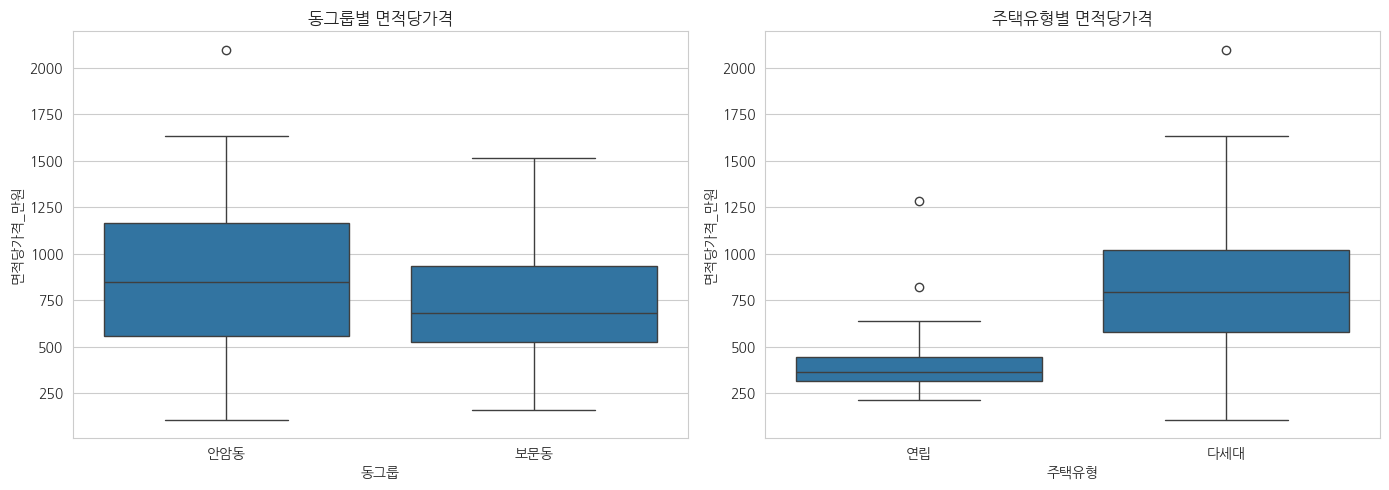

         평균면적당가격     평균전용면적   건수
주택유형                            
다세대   821.975693  27.928139  661
연립    412.668716  73.616061   33


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='동그룹', y=target, ax=axes[0]); axes[0].set_title('동그룹별 면적당가격')
sns.boxplot(data=df, x='주택유형', y=target, ax=axes[1]); axes[1].set_title('주택유형별 면적당가격')
plt.tight_layout()
plt.show()

type_stat = df.groupby('주택유형').agg(평균면적당가격=(target,'mean'), 평균전용면적=('전용면적_m2','mean'), 건수=('전용면적_m2','count'))
print(type_stat)

In [70]:
# "연립이 싸다"는 게 정말 주택유형 자체의 효과인지, 면적 차이로 이미 다 설명되는지 잔차로 확인
x = df['전용면적_m2'].values
y = df[target].values
slope, intercept = np.polyfit(x, y, 1)
df['잔차'] = y - (slope * x + intercept)  # 전용면적으로 설명 안 되는 나머지

resid_stat = df.groupby('주택유형')['잔차'].agg(['mean', 'std', 'count'])
print("=== 전용면적으로 설명되지 않는 잔차의 주택유형별 평균 ===")
print(resid_stat)

t_resid, p_resid = stats.ttest_ind(df[df['주택유형']=='다세대']['잔차'], df[df['주택유형']=='연립']['잔차'], equal_var=False)
print(f"\n잔차 t-test (면적 통제 후에도 주택유형 차이가 남는가): t={t_resid:.3f}  p={p_resid:.4f}")

=== 전용면적으로 설명되지 않는 잔차의 주택유형별 평균 ===
           mean         std  count
주택유형                              
다세대   -2.635828  267.158061    661
연립    52.796436  320.097169     33

잔차 t-test (면적 통제 후에도 주택유형 차이가 남는가): t=-0.978  p=0.3350


# 15. 갱신계약 인상률 — 전월세상한제(5%) 점검

In [71]:
renew = df[df['계약구분']=='갱신'].dropna(subset=['종전환산보증금_만원']).copy()
renew['증감율(%)'] = (renew['환산보증금_만원']-renew['종전환산보증금_만원'])/renew['종전환산보증금_만원']*100
print(f"갱신 계약 중 종전 정보 존재: {len(renew)}건")
print(renew['증감율(%)'].describe())
print(f"5.5% 초과 인상: {(renew['증감율(%)']>5.5).sum()}건")
print(renew.groupby('갱신요구권사용')['증감율(%)'].agg(['mean','median','count']))

갱신 계약 중 종전 정보 존재: 89건
count    89.000000
mean      3.770432
std       7.476345
min     -13.333333
25%       0.000000
50%       4.466501
75%       5.284553
max      34.000000
Name: 증감율(%), dtype: float64
5.5% 초과 인상: 20건
             mean    median  count
갱신요구권사용                           
         4.712131  4.826762     72
사용      -0.217941  0.000000     17


In [72]:
# 갱신요구권 사용여부에 따른 인상률 차이가 통계적으로 유의한지 (표본이 작아 비모수 검정 사용)
used = renew[renew['갱신요구권사용']=='사용']['증감율(%)']
unused = renew[renew['갱신요구권사용']!='사용']['증감율(%)']
u_stat, p_u = stats.mannwhitneyu(used, unused, alternative='two-sided')
print(f"사용(n={len(used)}) 평균={used.mean():.2f}%  미사용(n={len(unused)}) 평균={unused.mean():.2f}%")
print(f"Mann-Whitney U={u_stat:.1f}  p={p_u:.4f}")


사용(n=17) 평균=-0.22%  미사용(n=72) 평균=4.71%
Mann-Whitney U=362.0  p=0.0089


# <종합 정리 - 2차 EDA>


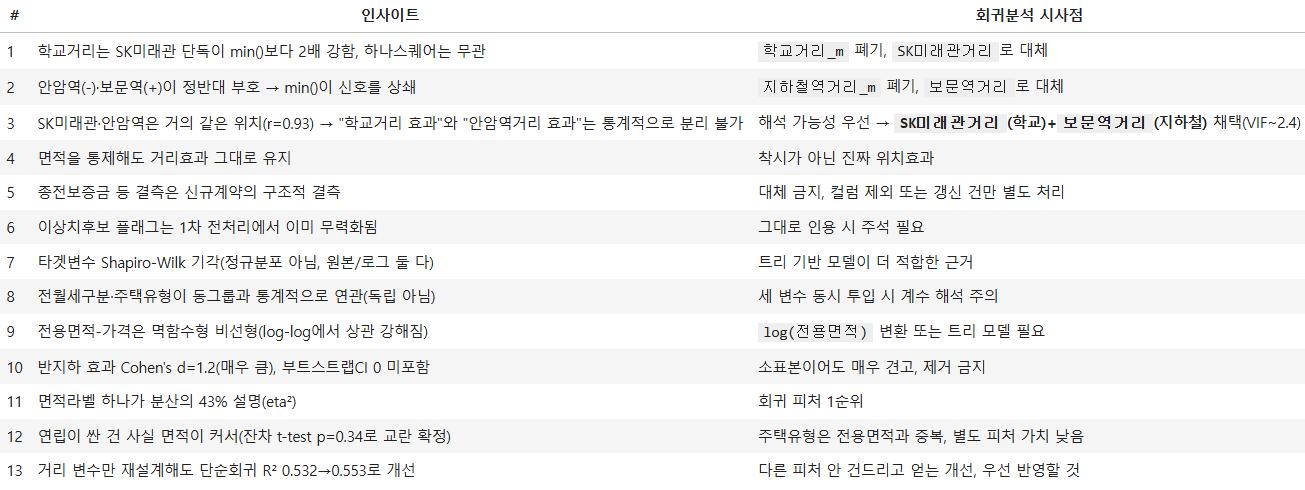

# <3차 전처리>

In [73]:
df = pd.read_csv("eda_안암보문_final.csv")
print(f"원본 데이터: {df.shape[0]}행 x {df.shape[1]}열")

원본 데이터: 1286행 x 42열


# 16. 거리 변수 재정의

In [74]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arctan2(np.sqrt(a), np.sqrt(1-a))

SK_LAT, SK_LON = 37.5843, 127.0305        # SK미래관 (학교)
BOMUN_LAT, BOMUN_LON = 37.58556, 127.01972  # 보문역 (지하철)

df['SK미래관거리'] = haversine(df['위도'], df['경도'], SK_LAT, SK_LON)
df['보문역거리'] = haversine(df['위도'], df['경도'], BOMUN_LAT, BOMUN_LON)

print("=== 재정의된 거리 변수 요약 ===")
print(df[['SK미래관거리', '보문역거리']].describe().round(1))

=== 재정의된 거리 변수 요약 ===
       SK미래관거리   보문역거리
count   1286.0  1286.0
mean     778.8   503.4
std      311.8   287.1
min       45.0   108.0
25%      525.5   254.1
50%      874.6   408.3
75%     1066.3   808.2
max     1232.6  1051.1


# 17. 면적 비선형성 대응



*   '`log_전용면적`' 변수 생성



In [76]:
df['log_전용면적'] = np.log(df['전용면적_m2'])
print(df[['전용면적_m2', 'log_전용면적']].describe().round(3))

        전용면적_m2  log_전용면적
count  1286.000  1286.000
mean     29.951     3.203
std      21.848     0.595
min       9.300     2.230
25%      14.160     2.650
50%      22.450     3.111
75%      37.930     3.636
max     162.730     5.092


# 18. 타겟 변수 확정

In [77]:
TARGET = '면적당가격_만원'
print(f"확정 타겟: {TARGET}")
print(df[TARGET].describe().round(1))

확정 타겟: 면적당가격_만원
count    1286.0
mean      802.8
std       346.5
min       108.3
25%       552.1
50%       781.6
75%      1017.9
max      2094.8
Name: 면적당가격_만원, dtype: float64


# 19. 구조적 결측 처리 방침

In [78]:
structural_na_cols = ['종전보증금_만원', '종전월세_만원', '종전환산보증금_만원']
print("=== 구조적 결측 컬럼 현황 (그대로 유지) ===")
print(df[structural_na_cols].isnull().sum())
print()
print(f"신규 계약 건수와 결측 건수 일치 확인: {(df['계약구분']=='신규').sum()} == {df['종전보증금_만원'].isnull().sum()}")

=== 구조적 결측 컬럼 현황 (그대로 유지) ===
종전보증금_만원      1109
종전월세_만원       1109
종전환산보증금_만원    1109
dtype: int64

신규 계약 건수와 결측 건수 일치 확인: 1109 == 1109


# 20. 이상치 플래그 처리

In [79]:
print(f"이상치후보 True 비율: {(df['이상치후보']==True).mean()*100:.1f}% (참고용, 모델링 제외)")

이상치후보 True 비율: 0.0% (참고용, 모델링 제외)


# 21. 범주형 변수 인코딩

In [80]:
dummy_cols = ['전월세구분', '주택유형', '동그룹', '최근접역', '면적라벨']
dummies = pd.get_dummies(df[dummy_cols], prefix=dummy_cols, drop_first=True).astype(int)
df = pd.concat([df, dummies], axis=1)
print("=== 생성된 더미 변수 ===")
print(dummies.columns.tolist())
print()
print(dummies.sum())

=== 생성된 더미 변수 ===
['전월세구분_전세', '주택유형_연립', '동그룹_안암동', '최근접역_안암역', '면적라벨_소형', '면적라벨_중형']

전월세구분_전세    253
주택유형_연립      62
동그룹_안암동     748
최근접역_안암역    383
면적라벨_소형     593
면적라벨_중형     323
dtype: int64


# 22. Train / Test 분할 (data_split 생성)

In [81]:
df['data_split'] = np.where(df['계약연도'] <= 2024, 'train', 'test')
print(df['data_split'].value_counts())

data_split
train    694
test     592
Name: count, dtype: int64


# 23. 최종 모델링 피처셋 정의

In [82]:
MODEL_FEATURES = [
    '전용면적_m2', 'log_전용면적',   # 원본 + 비선형 대응 (회귀엔 log_전용면적 권장, 트리 모델엔 원본도 무방)
    '층', '주택연령',
    'is_basement',
    'SK미래관거리', '보문역거리',      # 재정의된 거리 변수
]
# 아래는 선택적 피처 (동시 투입 시 8번 발견 참고해서 신중히)
OPTIONAL_FEATURES = [c for c in dummies.columns if c.startswith(('전월세구분_', '동그룹_', '최근접역_'))]
# 주택유형 더미는 전용면적과 중복 정보라 기본 제외 (원하면 dummies에서 가져다 쓰면 됨)

print("=== 기본 모델링 피처 ===")
print(MODEL_FEATURES)
print()
print("=== 선택적 피처 (신중히 투입) ===")
print(OPTIONAL_FEATURES)
print()
print("=== 기본 피처셋 결측치 확인 ===")
print(df[MODEL_FEATURES + [TARGET]].isnull().sum().sum(), "건 (0이어야 정상)")

=== 기본 모델링 피처 ===
['전용면적_m2', 'log_전용면적', '층', '주택연령', 'is_basement', 'SK미래관거리', '보문역거리']

=== 선택적 피처 (신중히 투입) ===
['전월세구분_전세', '동그룹_안암동', '최근접역_안암역']

=== 기본 피처셋 결측치 확인 ===
0 건 (0이어야 정상)


# 24. 최종 검증 & 저장

In [83]:
print(f"최종 데이터: {df.shape[0]}행 x {df.shape[1]}열")
print(f"Train: {(df['data_split']=='train').sum()}행 / Test: {(df['data_split']=='test').sum()}행")
print()
print("=== Train 기준 기본 피처 요약 ===")
train_df = df[df['data_split']=='train']
print(train_df[MODEL_FEATURES + [TARGET]].describe().round(2))

최종 데이터: 1286행 x 52열
Train: 694행 / Test: 592행

=== Train 기준 기본 피처 요약 ===
       전용면적_m2  log_전용면적       층    주택연령  is_basement  SK미래관거리    보문역거리  면적당가격_만원
count   694.00    694.00  694.00  694.00       694.00   694.00   694.00    694.00
mean     30.10      3.21    3.47   12.41         0.01   787.21   504.92    802.51
std      21.58      0.59    1.71    8.56         0.11   302.63   284.30    347.92
min      11.99      2.48   -1.00    1.00         0.00    44.98   107.98    108.28
25%      14.43      2.67    2.00    7.00         0.00   525.50   255.61    536.71
50%      22.91      3.13    3.00   11.00         0.00   874.59   408.25    779.21
75%      39.65      3.68    4.00   15.00         0.00  1066.29   801.79   1008.69
max     162.73      5.09   12.00   84.00         1.00  1189.42  1051.08   2094.83


In [85]:
SAVE_PATH = 'dataset_final_ML1조.csv'
df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
print(f"저장 완료: {SAVE_PATH}")

저장 완료: dataset_final_ML1조.csv
